# Lecture Week 9: Making Predictions - Simple regression

In [3]:
import pandas as pd
import seaborn as sns

## The Housing dataset

In [5]:
housingPath = 'housingData.csv'
housing = pd.read_csv(housingPath)
print(housing.shape)
print(housing.columns)

(4600, 18)
Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='str')


In [6]:
print(housing.price.sort_values()[:5]) # maybe missing values replaced with 0

4567    0.0
4588    0.0
4542    0.0
4374    0.0
4358    0.0
Name: price, dtype: float64


In [7]:
housing = housing.query('sqft_living < 8000 and price < 1000000 and price > 0') 
# prcie =0? housing.price.sort_values()[:5]

#create a new column of True and False
housing['has_basement'] = housing['sqft_basement'].apply(lambda x: True if x > 0 else False) 
print(f'sqft_basement column values:\n{housing.sqft_basement.sort_values().head()}')
print(f'\nhas_basement column values:\n{housing.has_basement.head()}')

# Drop unnecessary columns from the 'housing' DataFrame
housing = housing.drop(columns=['date','street','city','statezip','country',
                                'sqft_lot','yr_renovated','sqft_basement'])
print("\n", housing.shape) # droping columns and filtering rows

sqft_basement column values:
4577    0
33      0
35      0
36      0
2957    0
Name: sqft_basement, dtype: int64

has_basement column values:
0    False
2    False
3     True
4     True
5    False
Name: has_basement, dtype: bool

 (4207, 11)


In [8]:
housing.info()

<class 'pandas.DataFrame'>
Index: 4207 entries, 0 to 4599
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         4207 non-null   float64
 1   bedrooms      4207 non-null   float64
 2   bathrooms     4207 non-null   float64
 3   sqft_living   4207 non-null   int64  
 4   floors        4207 non-null   float64
 5   waterfront    4207 non-null   int64  
 6   view          4207 non-null   int64  
 7   condition     4207 non-null   int64  
 8   sqft_above    4207 non-null   int64  
 9   yr_built      4207 non-null   int64  
 10  has_basement  4207 non-null   bool   
dtypes: bool(1), float64(4), int64(6)
memory usage: 365.6 KB


In [9]:
housing.head()

,price,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,sqft_above,yr_built,has_basement
0,313000.0,3.0,1.50,1340,1.5,0,0,3,1340,1955,False
2,342000.0,3.0,2.00,1930,1.0,0,0,4,1930,1966,False
3,420000.0,3.0,2.25,2000,1.0,0,0,4,1000,1963,True
4,550000.0,4.0,2.50,1940,1.0,0,0,4,1140,1976,True
5,490000.0,2.0,1.00,880,1.0,0,0,3,880,1938,False


## How to identify correlations with a scatterplot
Create a scatter plot using seaborn's relplot:
`seaborn.relplot(data=None, x=None, y=None)`

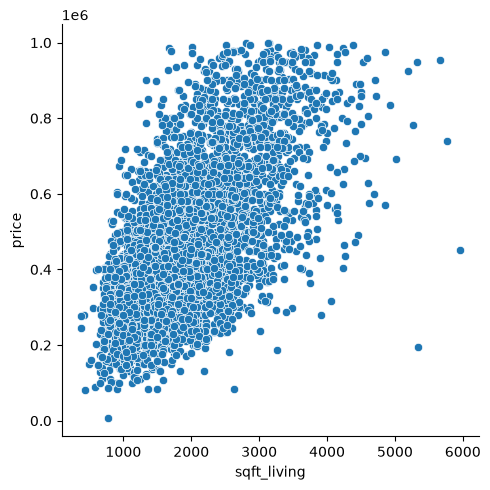

In [11]:
# The 'data' parameter is set to the 'housing' DataFrame
# The 'x' parameter is set to 'sqft_living' column and the 'y' parameter is set to 'price' column
sns.relplot(data=housing, x='sqft_living', y='price') # two numeric columns: x,y

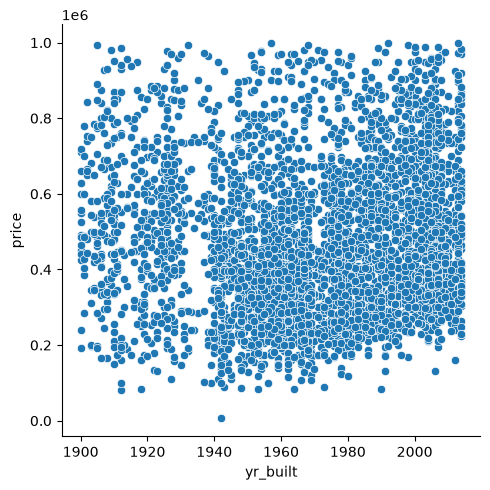

In [12]:
# The 'x' parameter is set to 'yr_built' column and the 'y' parameter is set to 'price' column
sns.relplot(data=housing, x='yr_built', y='price') # not much related! same year has different prices

## How to identify correlations with a grid of scatterplots
`.corr()` is a Pandas method that calculates the correlation between **numerical columns** in a DataFrame.
```python
df.corr()
```
It returns a **correlation matrix** showing the direction and strength of the linear relationship between **every pair of numerical columns**.

To calculate the correlation **between only two** Series:
```python
df['column1'].corr(df['column2'])
```

By default, Pandas uses **Pearson correlation**:

```python
students.corr(method='pearson')
```
Other available methods include:
```python
students.corr(method='spearman')
students.corr(method='kendall')
```

<div style="background-color:#fff3cd; border-left:5px solid #f0ad4e;
            padding:12px; border-radius:5px;">
  <strong>⚠️ Important:</strong> Correlation does not prove that one variable causes the other.
</div>


Ex:

Create a DataFrame with two variables: height and weight.

Both height and weight are strictly increasing.

In [15]:
data = {'height': [165, 170, 175, 180, 185], 'weight': [60, 70, 80, 90, 100]}
# change 70 t0 55 and see the impact
df = pd.DataFrame(data)
# Calculate the correlation matrix between height and weight
corr_matrix = df.corr()
# Print the correlation matrix
print(corr_matrix)

        height  weight
height     1.0     1.0
weight     1.0     1.0


- **1.0** on the **diagonal** means each variable is perfectly correlated with **itself**.
- The correlation between height and weight is 1.0.
- This is a **perfect positive correlation**: as height increases, weight also increases **consistently**.



`sns.pairplot()` creates **several plots** to show the **relationships** among the **numerical** variables in a dataset.

It produces a grid:

- **Diagonal**: shows the distribution of each variable, usually as a **histogram**.
- **Off-diagonal**: shows a **scatterplot** for each pair of variables.

<div style="background-color:#e8f4fd; border-left:5px solid #2196F3;
            padding:12px; border-radius:5px;">
  <strong>💡 Important:</strong> The <code>sns.pairplot()</code> output is a
  <strong>symmetric grid</strong>, and the scatterplots are
  <strong>transposed across the diagonal</strong>.
<al**.

Create a pairplot using seaborn's pairplot function
The `'x_vars'` and `'y_vars'` parameters are set to `'price'`, `'sqft_living'`, `'sqft_above'`
The `'diag_kind'` parameter is set to `'kde'` to display kernel density estimates on the diagonal.

                price  sqft_living  sqft_above
price        1.000000     0.607379    0.517395
sqft_living  0.607379     1.000000    0.848312
sqft_above   0.517395     0.848312    1.000000


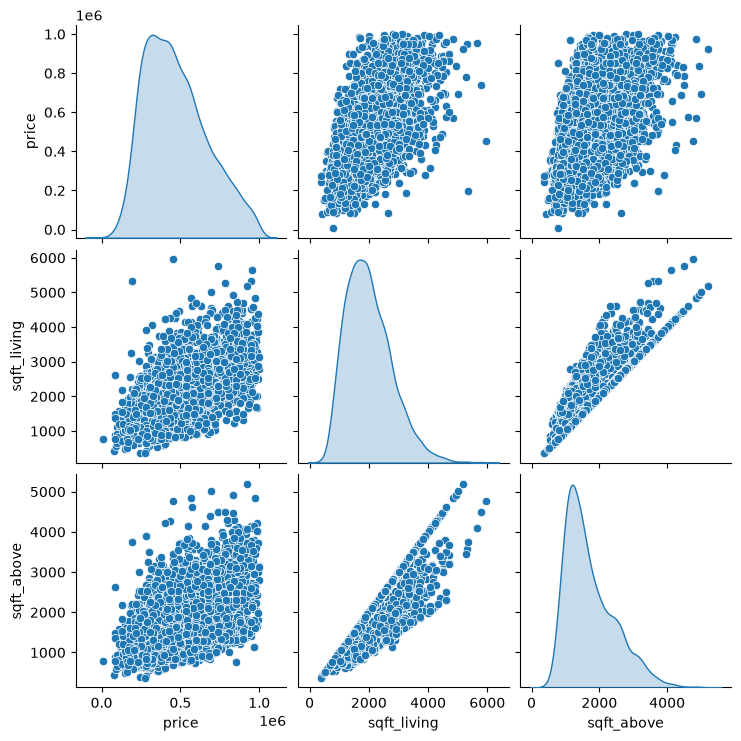

In [18]:
print(housing[['price','sqft_living','sqft_above']].corr())
sns.pairplot(data=housing,
             y_vars=['price','sqft_living','sqft_above'], 
             x_vars=['price','sqft_living','sqft_above'], # any columns can be selected for x and y
             diag_kind='kde' # if silent gives Histogram
            );

## How to identify correlations with r-values
Calculate the correlation matrix using corr()

In [20]:
correlation_matrix = housing.corr()
correlation_matrix

,price,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,sqft_above,yr_built,has_basement
price,1.000000,0.305046,0.460155,0.607379,0.272151,0.073671,0.196460,0.044926,0.517395,0.053012,0.152591
bedrooms,0.305046,1.000000,0.516726,0.603655,0.148377,-0.032263,0.060074,0.015105,0.466683,0.154287,0.157001
bathrooms,0.460155,0.516726,1.000000,0.715626,0.495380,0.020700,0.112797,-0.145555,0.637045,0.521801,0.127437
sqft_living,0.607379,0.603655,0.715626,1.000000,0.325647,0.030473,0.184432,-0.086310,0.848312,0.331001,0.175223
floors,0.272151,0.148377,0.495380,0.325647,1.000000,0.008710,-0.006647,-0.298350,0.526227,0.502039,-0.305249
waterfront,0.073671,-0.032263,0.020700,0.030473,0.008710,1.000000,0.321411,0.026089,0.020846,-0.037066,0.001688
view,0.196460,0.060074,0.112797,0.184432,-0.006647,0.321411,1.000000,0.041332,0.075312,-0.064988,0.152347
condition,0.044926,0.015105,-0.145555,-0.086310,-0.298350,0.026089,0.041332,1.000000,-0.209960,-0.394022,0.167838
sqft_above,0.517395,0.466683,0.637045,0.848312,0.526227,0.020846,0.075312,-0.209960,1.000000,0.456452,-0.294986
yr_built,0.053012,0.154287,0.521801,0.331001,0.502039,-0.037066,-0.064988,-0.394022,0.456452,1.000000,-0.198823


Ex:

1. Calculate the correlation matrix using corr().
2. Select only the `'price'` column using indexing and store it in a new DataFrame.
3. Sort the DataFrame by `'price'` column in descending order using the `sort_values()` method

In [22]:
correlation_with_price = housing.corr()[['price']].sort_values( by='price', ascending=False)
correlation_with_price

,price
price,1.000000
sqft_living,0.607379
sqft_above,0.517395
bathrooms,0.460155
bedrooms,0.305046
floors,0.272151
view,0.196460
has_basement,0.152591
waterfront,0.073671
yr_built,0.053012


## How to identify correlations with a heatmap
`sns.heatmap()` displays numerical values using colours. It is commonly used to visualise a correlation matrix.

`vmin=-1`, `vmax=1`: fixes the colour scale to the full correlation range.

The matrix is **symmetric**: the upper and lower triangles contain the same correlations.

Ex:

Create a heatmap of the correlation matrix using the `sns.heatmap()` function.
Pass the correlation matrix as the data argument.
Use the 'Blues' colormap for the heatmap.
Set the minimum and maximum values for the color scale using the vmin and vmax parameters.

<Axes: >

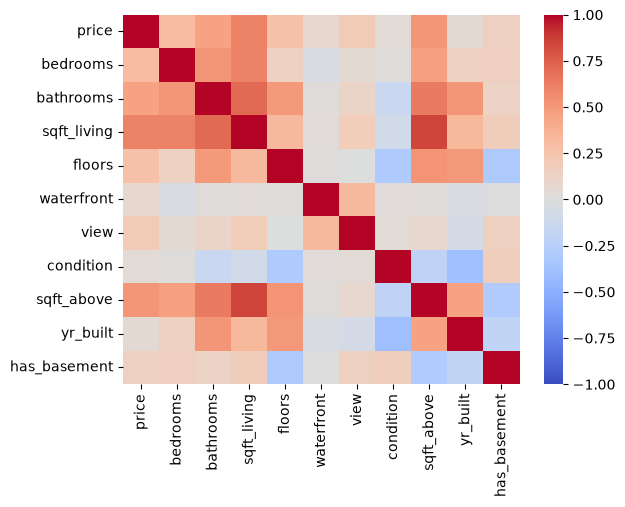

In [25]:
sns.heatmap(data=housing.corr(numeric_only=True), 
            cmap= 'coolwarm', #'Blues'
            vmin=-1.0, vmax=1.0) 
# For a correlation heatmap, −1 to +1 is generally the best and most correct range.

Ex:

Create a heatmap of the correlation matrix of `'housing'` DataFrame with only the `'price'` column.
Sort the correlations by the `'price'` column in descending order.
Use the `sns.heatmap()` function with the specified parameters:
- Pass the correlation matrix with only the `'price'` column as the data argument
- Set `annot=True` to **show the correlation values** as annotations.
- Use the `'Blues'` colormap for the heatmap.
- Set `cbar=False` to **hide the color bar**.
- Use `fmt='.2f'` to **format the annotations** as floating-point numbers with **2 decimal places**.

<Axes: >

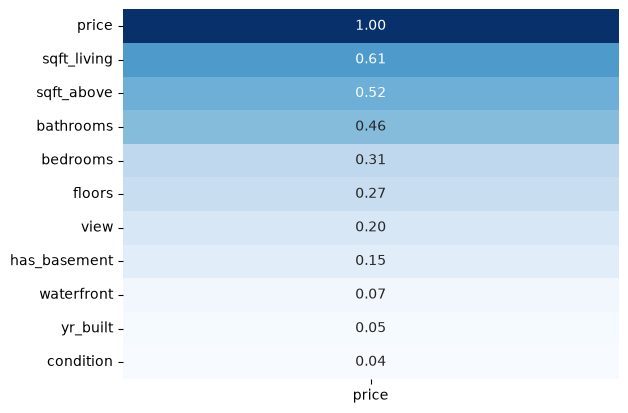

In [27]:
sns.heatmap(data=housing.corr()[['price']].sort_values(by='price', ascending=False), 
            annot=True, 
            cmap='Blues', 
            cbar=False, 
            fmt='.2f')

## How to create, validate, and use a linear regression model
The `train_test_split` function is used to split the dataset into training and testing sets.

The `LinearRegression` class is used to train the model on the training set 
 and evaluate its performance on the testing set.

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

Ex:

We use the housing data frame to split the data, selecting the `'sqft_living'` column as the **feature** and the `'price'` column as the **target**.

- `test_size=0.33` means that 33% of the data will be used for testing and 67% for training.

- The **random_state** parameter sets the random seed for **reproducibility**.

In [31]:
# The function train_test_split is used to split the data into training and test sets.
# The resulting four variables represent the feature and target splits for both training and testing data.
x_train, x_test, y_train, y_test = train_test_split(housing[['sqft_living']], 
                                                    housing[['price']], 
                                                    test_size=0.33, random_state=42)
print(type(x_test), len(x_test))
display( x_test.head())
# Create the linear regression model from the training dataset
# In this line, we create an instance of the LinearRegression class, 
# which represents the linear regression model.
linearModel = LinearRegression()

# We use the fit() method of the LinearRegression instance to train the model using the training data.
# The fit() method takes the feature (x_train) and target (y_train) data as arguments.
linearModel.fit(x_train, y_train)#; # returns the fitted model itself

<class 'pandas.DataFrame'> 1389


,sqft_living
1855,1240
3834,2450
2755,1950
4364,2280
4286,2410


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[157.05]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['sqft_living']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[160591.26]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


$$Predicted price=160591.26+157.05(`sqft_living`)$$

Interpretation:

- **Coefficient** 157.05: For each additional square foot of living space, the predicted house price increases by approximately $157.05, on average.
- **Intercept** 160591.26: The predicted price when sqft_living = 0. This is **mathematically required, although it may not have a useful real-world interpretation.**

In [33]:
# Once the model is trained, it will be able to predict the target values for new feature data.
# Use the linear model to make predictions
y_predicted = linearModel.predict(x_test)
# Combine the x_test, y_test, and y_predicted values into a single dataframe
# Validate the linear model with the test dataset
# The score() method of the LinearRegression instance is used to validate the model using the test data.
# The score() method takes the feature (x_test) and target (y_test) data as arguments.
# It returns the R-squared score of the model, which indicates how well the model fits the data.
print(linearModel.score(x_test, y_test))

0.35072654653322355


<div style="background-color: #ffe4ec; padding: 15px; border-radius: 8px; border-left: 5px solid #e75480;">

<b><code>linearModel.score(x_test, y_test)</code></b>

It first predicts:

<code>y_predicted = linearModel.predict(x_test)</code>

and then calculates the <b>R² score</b> by comparing:

<b>y_test ↔ y_predicted</b><br>
Actual values ↔ Predicted values

</div>

## How to plot the predicted data

In [36]:
predicted = pd.DataFrame(y_predicted, columns=['price_predicted'])
# Combine the test data and the predicted data
combined = predicted.join([x_test.reset_index(drop=True),
                           y_test.reset_index(drop=True)])
combined.head()

,price_predicted,sqft_living,price
0,355333.117428,1240,390000.0
1,545363.476872,2450,345000.0
2,466838.534953,1950,375000.0
3,518664.996619,2280,500324.0
4,539081.481518,2410,600000.0


,sqft_living,price_type,price_value
0,1240,price,390000.000000
1,2450,price,345000.000000
2,1950,price,375000.000000
3,2280,price,500324.000000
4,2410,price,600000.000000
...,...,...,...
2773,2280,price_predicted,518664.996619
2774,940,price_predicted,308218.152277
2775,1050,price_predicted,325493.639499
2776,1620,price_predicted,415012.073286


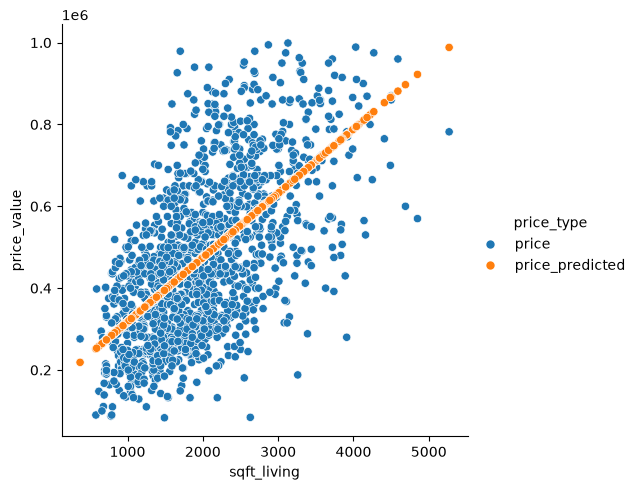

In [37]:
# Melt price and price_predicted columns into a single column
melted = pd.melt(combined, id_vars=['sqft_living'], 
                 value_vars=['price','price_predicted'], 
                 var_name='price_type', value_name='price_value')
display(melted)
# Create a scatter plot using Seaborn to visualize the melted data
sns.relplot(data=melted, x='sqft_living', y='price_value', hue='price_type');

## How to plot the residuals
In a good residual plot, points **should be randomly scattered above and below the $(y=0)$ line**, without a clear pattern.

```python
ax.axhline(
    y=0,
    xmin=0,
    xmax=1,
    color='red',
    linestyle='--',
    linewidth=2
)
```
> **⚠️ Important:** `xmin` and `xmax` use relative axes positions from `0` to `1`, not the actual values on the `x`-axis.
It means `xmin` and `xmax` specify fractions of the graph’s width, rather than values from your dataset.

- `xmin=0`: start at the far-left edge.
- `xmax=1`: finish at the far-right edge.
 
Therefore, the line covers 100% of the graph’s width.

- `ax.axhline()` uses relative positions from 0 to 1.
- `ax.hlines()` uses actual \(x\)-axis values.

,price_predicted,sqft_living,price,residual
0,355333.117428,1240,390000.0,34666.882572
1,545363.476872,2450,345000.0,-200363.476872
2,466838.534953,1950,375000.0,-91838.534953
3,518664.996619,2280,500324.0,-18340.996619
4,539081.481518,2410,600000.0,60918.518482


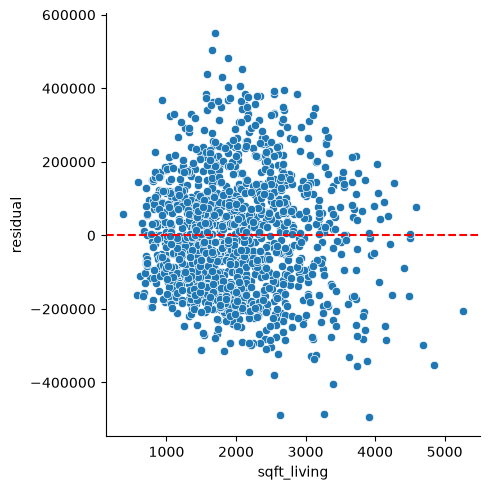

In [39]:
# Calculate residuals and add them as a new column to the combined DataFrame
combined['residual'] = combined.price - combined.price_predicted
display(combined.head())
# Create a scatter plot using Seaborn to visualize the combined data with residuals
g = sns.relplot(data=combined, x='sqft_living', y='residual')
# Draw a horizontal line where the Y axis is 0
for ax in g.axes.flat:    
    ax.axhline(y=0, ls='--', color='red')

## How to plot a linear regression
Scatter plot and regression line that best fits the data points.

`sns.lmplot()` is a Seaborn function that creates a scatterplot with a fitted regression line.

This displays:

- **Each observation** as a **point**.
- A regression line showing the estimated linear relationship.
- A **shaded confidence interval** around the regression line.
- `kws` stands for **keyword arguments**. The dictionary contains the additional keyword settings passed to the corresponding Matplotlib plotting function.

In [ ]:
# Create a scatter plot with a red regression line using Seaborn
# The scatter plot with 'sqft_living' values on the x-axis and 'price' values on the y-axis.  
# This line can be used to make predictions about the 'price' for any given 'sqft_living' value.

sns.lmplot(data=housing,        # The dataset to use
           x='sqft_living',     # The column to use for the x-axis
           y='price',           # The column to use for the y-axis
           ci=None,             # The size of the confidence interval for the regression line. 
                                # Remove the confidence interval: None
           scatter_kws={'s':1,'color': 'blue','alpha': 0.2}, # Additional scatter plot settings (size of markers)
           line_kws={'color':'red', 'linewidth': 2, 'linestyle': '--'}, # Additional regression line settings (color)
           # fit_reg=False
           # order=2               # Fit a second-degree polynomial curve:
          );  

## How to plot a logistic regression
`sns.lmplot()` can visualise a logistic regression curve when the dependent variable is binary, such as **0/1, No/Yes, or Fail/Pass**.

Use `sns.lmplot(logistic=True)` to visualise the relationship and `sklearn.LogisticRegression` to build and evaluate the predictive model.

A predicted value of 0.80 on the curve means an estimated 80% probability of passing, not that the observed outcome is 0.80.

Without `logistic=True`, `lmplot()` fits an ordinary linear regression line, which is generally inappropriate for binary outcomes because it may produce predictions below 0 or above 1.

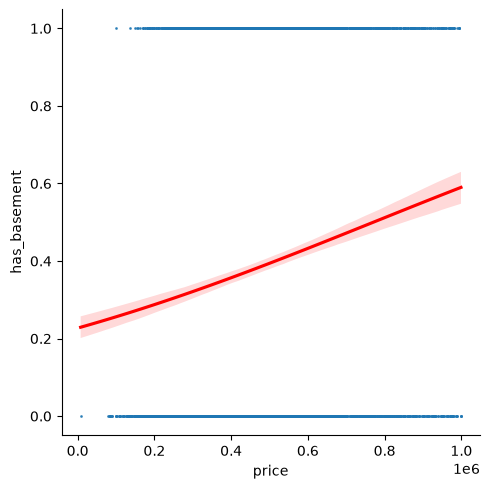

In [43]:
# Create a logistic regression plot with a red line using Seaborn
sns.lmplot(data=housing,         # The dataset to use
           x='price',            # The column to use for the x-axis
           y='has_basement',     # The column to use for the y-axis
           ci=95,                # Set the size of the confidence interval to 95%
           scatter_kws={'s':1},  # Additional scatter plot settings (size of markers)
           line_kws={'color':'red'},  # Additional regression line settings (color)
           logistic=True);       # Use logistic regression instead of linear regression

# The logistic regression line models the probability of having a basement given the price of the house.
# The x-axis shows the prices, and the y-axis shows whether the house has a basement or not (0 or 1).
# The red line represents the logistic regression model, 
# which estimates the probability of having a basement based on the house price.
# As the price increases, the probability of having a basement also increases, 
# up to a certain point where the probability levels off.

# The ci parameter sets the size of the confidence interval for the logistic regression line. 
# A confidence interval is a range within which the regression line is likely to fall, with a specified level of confidence. 
# In this case, the ci parameter is set to 95%, indicating that we are 95% confident
# that the regression line falls within the specified range.

## How to plot a polynormal regression
The regression line is computed using a polynomial function of the form $y = b_0 + b_1x + b_2x^2 + ... + b_nx^n$,
where n is the degree of the polynomial. A polynomial regression line can fit the data better than a linear
regression line if there is a nonlinear relationship between the x and y variables.

In [45]:
# Load mortality data from a pickle file and display the first few rows
mortality_data = pd.read_pickle('mortality_data.pkl')
mortality_data.head()

,Year,AgeGroup,DeathRate
0,1900,01-04 Years,1983.8
1,1901,01-04 Years,1695.0
2,1902,01-04 Years,1655.7
3,1903,01-04 Years,1542.1
4,1904,01-04 Years,1591.5


This code examines how death rate changes over time for different age groups.
It creates a scatterplot and fits a separate cubic regression curve for each age group.

Fits a cubic polynomial model:
$$ \text{DeathRate} = b_0+b_1(\text{Year})+b_2(\text{Year})^2+b_3(\text{Year})^3 $$

A cubic curve can bend and change direction, allowing it to capture a more complex trend than a straight line.

Diamond points: average death rates within the 20 year bins

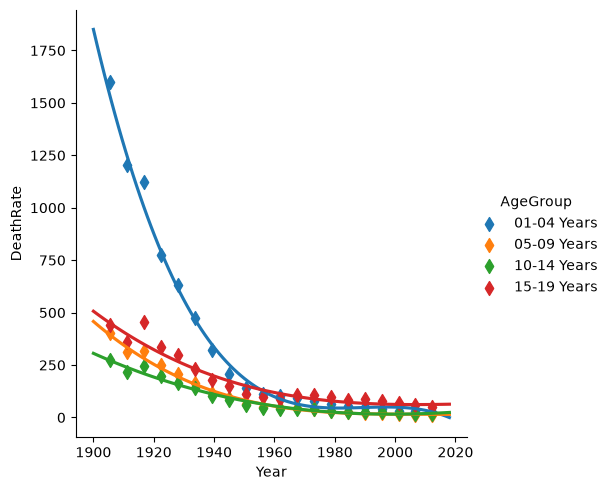

In [47]:
# Create a polynomial regression plot using Seaborn
sns.lmplot(x='Year',                # The column to use for the x-axis
           y='DeathRate',           # The column to use for the y-axis
           hue='AgeGroup',          # Group the data by AgeGroup and color-code the groups
           data=mortality_data,     # The dataset to use
           ci=None,                 # Do not show confidence intervals for the regression line
           markers='d',             # Set the marker style for the scatter plot (diamond)
           x_bins=20,               # Divide the x-axis into 20 evenly-spaced bins
           order=3)                 # Fit a cubic (degree 3) polynomial regression line

# x_bins=20 divides the range of Year into 20 bins. 
# Within each bin and age group, Seaborn plots a summary estimate—by default, 
# the mean death rate—rather than every individual observation.
# Importantly, the polynomial curve is still fitted using the original observations. 
# The bins mainly simplify the displayed scatter points.

# The order parameter is used to specify the degree of the polynomial regression line. 
# In this case, we are fitting a cubic (degree 3) polynomial regression line. 
# Higher-degree polynomial regression lines can fit the data even better,
# but they can also be more prone to overfitting.

## How to plot a lowess regression
This code creates a scatter plot of Year vs DeathRate for mortality data, 
where each data point is colored based on the AgeGroup it belongs to. 

Finally, lowess is set to True, indicating that a locally weighted regression line should be used.

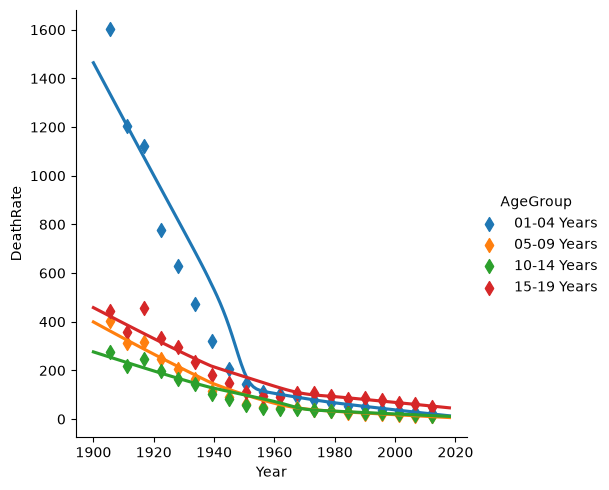

In [49]:
# Create a scatter plot with a regression line for each age group using Seaborn
sns.lmplot(data=mortality_data,            # The dataset to use
           x='Year',                      # The column to use for the x-axis
           y='DeathRate',                 # The column to use for the y-axis
           hue='AgeGroup',                # Group the data by AgeGroup and show different colors
           ci=None,                       # The size of the confidence interval for the regression line
           markers='d',                   # The type of marker to use
           x_bins=20,                     # Number of bins to discretize the x-axis into
           lowess=True)                   # Whether to use a locally weighted regression line (lowess)

## How to plot residuals with Seaborn
This creates a residual plot to examine whether a linear regression model is appropriate for predicting house price from living area.

For each house, Seaborn fits a linear regression model:
$$ \text{Predicted price}=b_0+b_1(\text{sqft living}) $$
And then, calculates the residual:
$$Residual=Actual Price−Predicted Price$$

A suitable linear model should generally produce points randomly scattered around the horizontal line at zero:

<div style="background-color:#eef6ff; border-left:5px solid #2196F3;
            padding:12px; border-radius:6px; line-height:1.8;">

<strong>💡 How to interpret a residual plot:</strong><br>

✅ <strong>Random pattern around zero</strong> → A linear model may be appropriate.<br>

〰️ <strong>Curved pattern</strong> → A nonlinear model may be needed.<br>

🔺 <strong>Funnel shape</strong> → The error variance changes across <em>x</em>.<br>

⚠️ <strong>Extreme isolated points</strong> → Possible outliers.

</div>

<div style="background-color:#e8f4fd; border:2px solid #2196F3;
            color:#0B4F8A; padding:14px; border-radius:8px;
            text-align:center; font-size:17px;">

<strong>A good residual plot does not mean that every residual is zero.</strong><br>
It means the residuals **show no clear systematic pa**ttern around zero.

</div>

<div style="background-color:#fff3cd; border:2px solid #f0ad4e;
            color:#664d03; padding:14px; border-radius:8px;
            line-height:1.8;">

<div style="text-align:center; font-size:18px;">
<strong>Residual = Actual value − Predicted value</strong><br>
<strong>e = y − ŷ</strong>
</div>

<hr style="border:none; border-top:1px solid #f0ad4e;">

<strong>Residual &gt; 0:</strong> The actual price is higher than predicted, so the model <strong>underestimated</strong>.<br>

<strong>Residual &lt; 0:</strong> The actual price is lower than predicted, so the model <strong>overestimated</strong>.<br>

<strong>Residual ≈ 0:</strong> The predicted price is close to the actual price.

</div>

Text(0.5, 0, 'Living area (sq ft)')

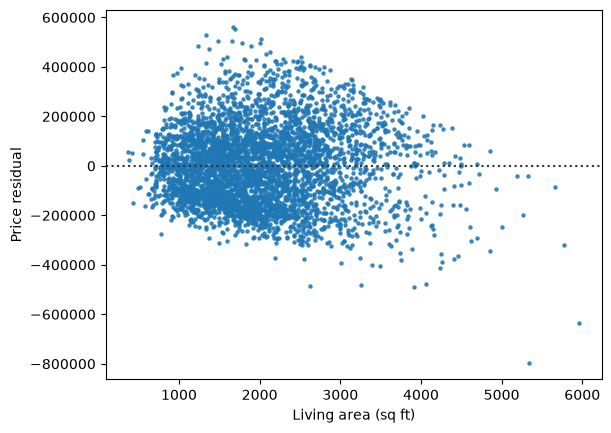

In [53]:
# Create a residual plot using Seaborn
ax = sns.residplot(data=housing, x='sqft_living', y='price', scatter_kws={'s':5})
ax.set_ylabel('Price residual')
ax.set_xlabel('Living area (sq ft)')

### Interpretation
- The residuals are distributed above and below the zero line, so the model sometimes underestimates and sometimes overestimates house prices.
- The points form a wide, uneven or funnel-like pattern rather than a consistent band. This suggests heteroscedasticity: prediction errors do not have constant variance across house sizes.
- For larger houses, particularly above approximately 4,000 square feet, many residuals are below zero. This suggests the model often overestimates the prices of these larger houses.
- Several extreme negative residuals appear around 5,000–6,000 square feet. These may be outliers or influential observations.
- The changing pattern may indicate that house size alone does not explain price sufficiently. Variables such as location, condition, number of bedrooms and land size may also be important.
- A nonlinear model, transformation, or multiple regression model may fit the data better.

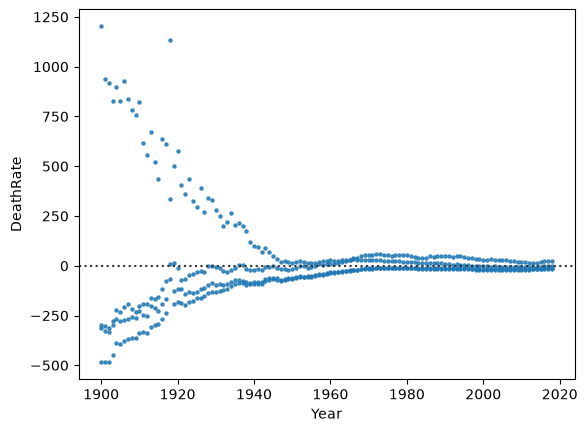

In [55]:
# Create a residual plot using Seaborn
sns.residplot(data=mortality_data, x='Year', y='DeathRate', order=3, scatter_kws={'s':5});

#### What the plot shows
- The residuals form clear curves and separate bands instead of being randomly scattered around zero.
- Before approximately 1950, the residuals are extremely large—ranging from about \(-500\) to \(+1{,}200\).
- After approximately 1950, residuals become much smaller and closer to zero.
- This produces a strong funnel pattern: the error variance decreases over time.
- The separate bands probably correspond to different age groups with very different death-rate levels.

Therefore, the model violates two important expectations:

- The residuals do not have constant variance.
- The residuals do not show a random pattern around zero.

Important modelling issue

This code fits one cubic model to all age groups together:
It does not account for AgeGroup. If death rates differ substantially among age groups, combining them into one curve creates misleading residual patterns.